# Health Claims Fact-Checker POC: End-to-End Walkthrough

This notebook walks through the complete POC — from corpus preparation to pipeline comparison to evaluation.

**Goal:** Validate the 3x2 study premise by comparing P1 (Naive RAG + Single-Pass) vs P6 (Advanced RAG + Multi-Agent).

**What you need before running:**
1. Run `uv sync` from the project root to install dependencies
2. Copy `.env.example` to `.env` and fill in your API keys:
   - `ANTHROPIC_API_KEY` — for P1 LLM calls
   - `AWS_ACCESS_KEY_ID`, `AWS_SECRET_ACCESS_KEY`, `AWS_DEFAULT_REGION` — for P6 (Bedrock/Strands)
3. Run this notebook with: `uv run jupyter notebook`

---
## 0. Setup & Imports

In [1]:
import json
import sys
import os
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure project root is on the path
os.chdir(os.path.join(os.path.dirname(os.getcwd()) if 'notebooks' in os.getcwd() else os.getcwd()))
sys.path.insert(0, os.getcwd())

print(f"Working directory: {os.getcwd()}")
print(f"Python: {sys.version}")

Working directory: /Users/ikhyvicky/Documents/MITB_stuff/CS614 -Gen AI/CS614-Group-Project
Python: 3.11.14 (main, Dec 17 2025, 21:09:14) [Clang 21.1.4 ]


---
## 1. Corpus Preparation

We fetch ~30 vaccine-related PubMed abstracts using Biopython's Entrez API, then chunk them for embedding.

**Key decisions:**
- 7 search queries covering vaccines, autism, vitamin D, mRNA, HPV, flu
- ~200 token chunks with 50 token overlap
- Stored as JSON for reproducibility

In [2]:
# Load the corpus (already fetched via scripts/fetch_corpus.py)
with open('data/corpus.json') as f:
    corpus = json.load(f)

print(f"Articles: {len(corpus)}")
print(f"Year range: {min(a['year'] for a in corpus if a['year'])} - {max(a['year'] for a in corpus if a['year'])}")
print(f"Avg abstract length: {sum(len(a['abstract'].split()) for a in corpus) / len(corpus):.0f} words")
print(f"\nSample article:")
print(f"  PMID: {corpus[0]['pmid']}")
print(f"  Title: {corpus[0]['title'][:80]}...")
print(f"  Abstract: {corpus[0]['abstract'][:150]}...")

Articles: 36
Year range: 2004 - 2025
Avg abstract length: 211 words

Sample article:
  PMID: 39289418
  Title: COMPARING vaccine manufacturing technologies recombinant DNA vs in vitro transcr...
  Abstract: Vaccine manufacturing fosters the prevention, control, and eradication of infectious diseases. Recombinant DNA and in vitro (IVT) mRNA vaccine manufac...


In [3]:
# Load the chunked corpus
with open('data/corpus/processed/chunks.json') as f:
    chunks = json.load(f)

print(f"Total chunks: {len(chunks)}")
print(f"Chunks per article: {len(chunks) / len(corpus):.1f} avg")
print(f"\nSample chunk:")
print(f"  PMID: {chunks[0]['pmid']}")
print(f"  Chunk index: {chunks[0]['chunk_index']}")
print(f"  Text: {chunks[0]['text'][:200]}...")

Total chunks: 84
Chunks per article: 2.3 avg

Sample chunk:
  PMID: 39289418
  Chunk index: 0
  Text: Vaccine manufacturing fosters the prevention, control, and eradication of infectious diseases. Recombinant DNA and in vitro (IVT) mRNA vaccine manufacturing technologies were enforced to combat the re...


### Re-fetching the corpus (optional)

If you need to re-fetch from PubMed (e.g. corpus.json is missing), run:
```bash
uv run python scripts/fetch_corpus.py
```

Then re-chunk:

In [ ]:
# Uncomment to re-chunk the corpus:
# from src.shared.corpus_loader import load_corpus, chunk_corpus, save_processed_corpus
# corpus = load_corpus('data/corpus.json')
# chunks = chunk_corpus(corpus, chunk_size=200, overlap=50)
# save_processed_corpus(chunks)
# print(f"Chunked {len(corpus)} articles into {len(chunks)} chunks")

---
## 2. Embedding & Indexing

We embed all chunks using **NeuML/pubmedbert-base-embeddings** (a HuggingFace model trained on PubMed data) and store them in **ChromaDB** (local, no server needed).

**Why PubMedBERT over OpenAI embeddings?**
- No API key needed — runs locally
- Trained on PubMed title-abstract pairs — better for medical text
- 768-dim, 512 max tokens (vs all-MiniLM's 256 token limit which silently truncates)

In [4]:
from src.shared.vector_store import get_chroma_client, get_or_create_collection, add_documents, search
from src.shared.embeddings import DEFAULT_MODEL

print(f"Embedding model: {DEFAULT_MODEL}")

client = get_chroma_client()
collection = get_or_create_collection(client)

# Index if empty (already done if you ran the POC before)
if collection.count() == 0:
    print("Indexing chunks into ChromaDB...")
    with open('data/corpus/processed/chunks.json') as f:
        chunks = json.load(f)
    add_documents(collection, chunks)

print(f"Documents in ChromaDB: {collection.count()}")

Embedding model: NeuML/pubmedbert-base-embeddings


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Documents in ChromaDB: 84


In [5]:
# Test retrieval quality
test_queries = [
    "vaccines cause autism",
    "mRNA vaccine DNA alteration",
    "vitamin D prevents COVID",
]

for query in test_queries:
    hits = search(collection, query, top_k=3)
    print(f"\nQuery: \"{query}\"")
    for i, h in enumerate(hits, 1):
        print(f"  {i}. [PMID {h['metadata']['pmid']}] (dist={h['distance']:.3f}) {h['text'][:100]}...")


Query: "vaccines cause autism"
  1. [PMID 30986133] (dist=0.380) Autism is a developmental disability that can cause significant social, communication, and behaviora...
  2. [PMID 24814559] (dist=0.457) by exposure type (OR: 0.85, 95% CI: 0.76 to 0.95; p=0.01). Findings of this meta-analysis suggest th...
  3. [PMID 30831578] (dist=0.476) time periods after vaccination. No individual medical charts were reviewed. The study strongly suppo...

Query: "mRNA vaccine DNA alteration"
  1. [PMID 31022829] (dist=0.339) This review provides a comparison of the theoretical issues and experimental findings for plasmid DN...
  2. [PMID 37896985] (dist=0.393) applicability to DNA- and RNA-based vaccinations....
  3. [PMID 31022829] (dist=0.476) along with a comparison to DNA vaccines, specifically the immunogenicity of both licensed veterinary...

Query: "vitamin D prevents COVID"
  1. [PMID 32811354] (dist=0.280) <b></b>The widespread COVID-19 pandemic has been, currently, converted to a catastro

---
## 3. Test Claims

7 claims of varying difficulty, each with an expected verdict.

In [6]:
with open('data/test_claims.json') as f:
    test_claims = json.load(f)

df_claims = pd.DataFrame(test_claims)
df_claims.index += 1
df_claims

,claim,expected_verdict,difficulty
1,Vaccines cause autism,UNSUPPORTED,easy
2,The MMR vaccine is linked to autism in children,UNSUPPORTED,easy
3,Vitamin D supplements prevent COVID infection,OVERSTATED,nuanced
4,Intermittent fasting reverses Type 2 diabetes,OVERSTATED,nuanced
5,mRNA vaccines alter your DNA,UNSUPPORTED,mechanistic
6,COVID vaccines are effective against all variants,OVERSTATED,mixed_evidence
7,Flu vaccines reduce hospitalisation in elderly...,SUPPORTED,simple_supported


---
## 4. Pipeline Architectures

### P1: Naive RAG + Single-Pass
```
claim --> embed --> cosine similarity search (top-5) --> single LLM call --> verdict
```
- **Retrieval:** ChromaDB cosine similarity, raw claim as query
- **LLM:** Single Anthropic API call (Claude Sonnet 4)
- **Strengths:** Fast, cheap, simple
- **Weaknesses:** No claim decomposition, no re-ranking, single-shot reasoning

### P6: Advanced RAG + Multi-Agent (Strands SDK)
```
claim --> [Claim Parser] --> [Retrieval Agent] --> [Evidence Reviewer] --> [Verdict Agent] --> verdict
```
- **Agent 1 (Claim Parser):** Decomposes claim into 2-4 verifiable sub-claims with targeted PubMed queries
- **Agent 2 (Retrieval Agent):** Per sub-claim, searches ChromaDB + live PubMed API, re-ranks results
- **Agent 3 (Evidence Reviewer):** Flags contradictions, gaps, notes evidence quality
- **Agent 4 (Verdict Agent):** Synthesises final verdict addressing each sub-claim
- **LLM:** Claude Sonnet 4 via AWS Bedrock (same model as P1)
- **Strengths:** Nuanced verdicts, multi-source retrieval, structured reasoning
- **Weaknesses:** Slower, more expensive, more failure points

---
## 5. Run P1 on All Claims

~5-10 seconds per claim.

In [7]:
from src.pipelines.p1_naive_single.pipeline import run as run_p1

p1_results = []
for item in test_claims:
    claim = item['claim']
    print(f"P1: {claim[:60]}...", end=" ")
    result = run_p1(claim)
    match = 'Y' if result['verdict'] == item['expected_verdict'] else 'N'
    print(f"--> {result['verdict']} ({result['metadata']['latency_seconds']}s) [correct: {match}]")
    p1_results.append({**item, 'result': result})

p1_correct = sum(1 for r in p1_results if r['result']['verdict'] == r['expected_verdict'])
print(f"\nP1 accuracy: {p1_correct}/{len(p1_results)}")

P1: Vaccines cause autism... --> UNSUPPORTED (6.42s) [correct: Y]
P1: The MMR vaccine is linked to autism in children... --> UNSUPPORTED (5.82s) [correct: Y]
P1: Vitamin D supplements prevent COVID infection... --> UNSUPPORTED (5.31s) [correct: N]
P1: Intermittent fasting reverses Type 2 diabetes... --> INSUFFICIENT_EVIDENCE (3.15s) [correct: N]
P1: mRNA vaccines alter your DNA... --> UNSUPPORTED (4.4s) [correct: Y]
P1: COVID vaccines are effective against all variants... --> OVERSTATED (5.57s) [correct: Y]
P1: Flu vaccines reduce hospitalisation in elderly patients... --> UNSUPPORTED (5.74s) [correct: N]

P1 accuracy: 4/7


---
## 6. Run P6 on All Claims

~60-90 seconds per claim (4 agent calls + PubMed API). **This takes ~10 minutes total.**

In [8]:
from src.pipelines.p6_adv_multi.pipeline import run as run_p6

p6_results = []
for item in test_claims:
    claim = item['claim']
    print(f"P6: {claim[:60]}...", end=" ", flush=True)
    result = run_p6(claim)
    match = 'Y' if result['verdict'] == item['expected_verdict'] else 'N'
    print(f"--> {result['verdict']} ({result['metadata']['latency_seconds']}s) [correct: {match}]")
    p6_results.append({**item, 'result': result})

p6_correct = sum(1 for r in p6_results if r['result']['verdict'] == r['expected_verdict'])
print(f"\nP6 accuracy: {p6_correct}/{len(p6_results)}")

P6: Vaccines cause autism... I'll decompose this health claim into specific, verifiable sub-claims with targeted PubMed search queries.
Tool #1: ParsedClaimsOutput
I'll retrieve evidence for each of these sub-claims by searching both the local corpus and PubMed. Let me start with the searches.
Tool #1: search_local_corpus

Tool #2: search_pubmed_api

Tool #3: search_local_corpus

Tool #4: search_pubmed_api

Tool #5: search_local_corpus

Tool #6: search_pubmed_api

Tool #7: search_local_corpus

Tool #8: search_pubmed_api
Now I'll compile the top 3 most relevant passages for each sub-claim based on the search results and their relevance scores.
Tool #9: RetrievalOutput

Tool #1: ReviewedEvidence

Tool #1: VerdictOutput
--> UNSUPPORTED (98.49s) [correct: Y]
P6: The MMR vaccine is linked to autism in children... I'll decompose this health claim into specific, verifiable sub-claims with targeted PubMed search queries.
Tool #1: ParsedClaimsOutput
I'll search for evidence on each of these sub

---
## 7. Side-by-Side Verdict Comparison

In [9]:
comparison_rows = []
for p1, p6 in zip(p1_results, p6_results):
    comparison_rows.append({
        'Claim': p1['claim'][:50],
        'Expected': p1['expected_verdict'],
        'P1 Verdict': p1['result']['verdict'],
        'P6 Verdict': p6['result']['verdict'],
        'P1 Correct': p1['result']['verdict'] == p1['expected_verdict'],
        'P6 Correct': p6['result']['verdict'] == p6['expected_verdict'],
        'Agree': p1['result']['verdict'] == p6['result']['verdict'],
    })

df_verdicts = pd.DataFrame(comparison_rows)
df_verdicts.index += 1
df_verdicts.style.applymap(
    lambda v: 'background-color: #d4edda' if v is True else ('background-color: #f8d7da' if v is False else ''),
    subset=['P1 Correct', 'P6 Correct']
)

/var/folders/1q/pcrqby796fnbjgbr9ty_p12m0000gn/T/ipykernel_18730/3078902693.py:15: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  df_verdicts.style.applymap(


,Claim,Expected,P1 Verdict,P6 Verdict,P1 Correct,P6 Correct,Agree
1,Vaccines cause autism,UNSUPPORTED,UNSUPPORTED,UNSUPPORTED,True,True,True
2,The MMR vaccine is linked to autism in children,UNSUPPORTED,UNSUPPORTED,UNSUPPORTED,True,True,True
3,Vitamin D supplements prevent COVID infection,OVERSTATED,UNSUPPORTED,UNSUPPORTED,False,False,True
4,Intermittent fasting reverses Type 2 diabetes,OVERSTATED,INSUFFICIENT_EVIDENCE,OVERSTATED,False,True,False
5,mRNA vaccines alter your DNA,UNSUPPORTED,UNSUPPORTED,INSUFFICIENT_EVIDENCE,True,False,False
6,COVID vaccines are effective against all variants,OVERSTATED,OVERSTATED,OVERSTATED,True,True,True
7,Flu vaccines reduce hospitalisation in elderly pat,SUPPORTED,UNSUPPORTED,OVERSTATED,False,False,False


---
## 8. Explanation Quality: P1 vs P6 Examples

Looking at the claims where P1 and P6 diverge most.

In [10]:
# Show side-by-side explanations for each claim
for p1, p6 in zip(p1_results, p6_results):
    agree = p1['result']['verdict'] == p6['result']['verdict']
    marker = '' if agree else ' << DISAGREE'
    print(f"{'='*80}")
    print(f"CLAIM: {p1['claim']}")
    print(f"Expected: {p1['expected_verdict']}{marker}")
    print(f"{'='*80}")
    print(f"\n--- P1 [{p1['result']['verdict']}] ---")
    print(p1['result']['explanation'])
    print(f"\n--- P6 [{p6['result']['verdict']}] ---")
    print(p6['result']['explanation'])
    print()

CLAIM: Vaccines cause autism
Expected: UNSUPPORTED

--- P1 [UNSUPPORTED] ---
The evidence overwhelmingly contradicts the claim that vaccines cause autism. Multiple large-scale epidemiological studies, including meta-analyses covering over 1.2 million children, consistently show no association between vaccines and autism development. The original 1998 study suggesting this link was retracted, and extensive research demonstrates that autism has a strong genetic component with onset before typical vaccination ages.

--- P6 [UNSUPPORTED] ---
The claim that vaccines cause autism is directly contradicted by robust scientific evidence. A comprehensive meta-analysis (PMID:24814559) of over 1.2 million children found no relationship between vaccination and autism development (OR: 0.99; 95% CI: 0.92-1.06), with similar null findings for specific vaccine components like thimerosal and mercury. A large Danish nationwide cohort study (PMID:30831578) further confirmed that MMR vaccination does not i

---
## 9. Cost & Latency Comparison

In [11]:
perf_rows = []
for p1, p6 in zip(p1_results, p6_results):
    perf_rows.append({
        'Claim': p1['claim'][:45],
        'P1 Latency (s)': p1['result']['metadata']['latency_seconds'],
        'P6 Latency (s)': p6['result']['metadata']['latency_seconds'],
        'P1 Tokens': p1['result']['metadata']['total_tokens'],
        'P6 Tokens': p6['result']['metadata']['total_tokens'],
        'P1 Cost ($)': round(p1['result']['metadata']['estimated_cost_usd'], 4),
        'P6 Cost ($)': round(p6['result']['metadata']['estimated_cost_usd'], 4),
    })

df_perf = pd.DataFrame(perf_rows)
df_perf.index += 1

# Add totals row
totals = df_perf.select_dtypes(include='number').sum()
totals['Claim'] = 'TOTAL'
df_perf = pd.concat([df_perf, pd.DataFrame([totals])], ignore_index=True)
df_perf

,Claim,P1 Latency (s),P6 Latency (s),P1 Tokens,P6 Tokens,P1 Cost ($),P6 Cost ($)
0,Vaccines cause autism,6.42,98.49,1465.0,4271.0,0.0091,0.0384
1,The MMR vaccine is linked to autism in childr,5.82,95.46,1400.0,4518.0,0.0090,0.0407
2,Vitamin D supplements prevent COVID infection,5.31,162.44,1574.0,4844.0,0.0091,0.0436
3,Intermittent fasting reverses Type 2 diabetes,3.15,251.10,1396.0,3797.0,0.0054,0.0342
4,mRNA vaccines alter your DNA,4.40,105.28,838.0,4050.0,0.0051,0.0365
5,COVID vaccines are effective against all vari,5.57,82.02,1719.0,4482.0,0.0095,0.0403
6,Flu vaccines reduce hospitalisation in elderl,5.74,92.83,1364.0,5051.0,0.0078,0.0455
7,TOTAL,36.41,887.62,9756.0,31013.0,0.0550,0.2792


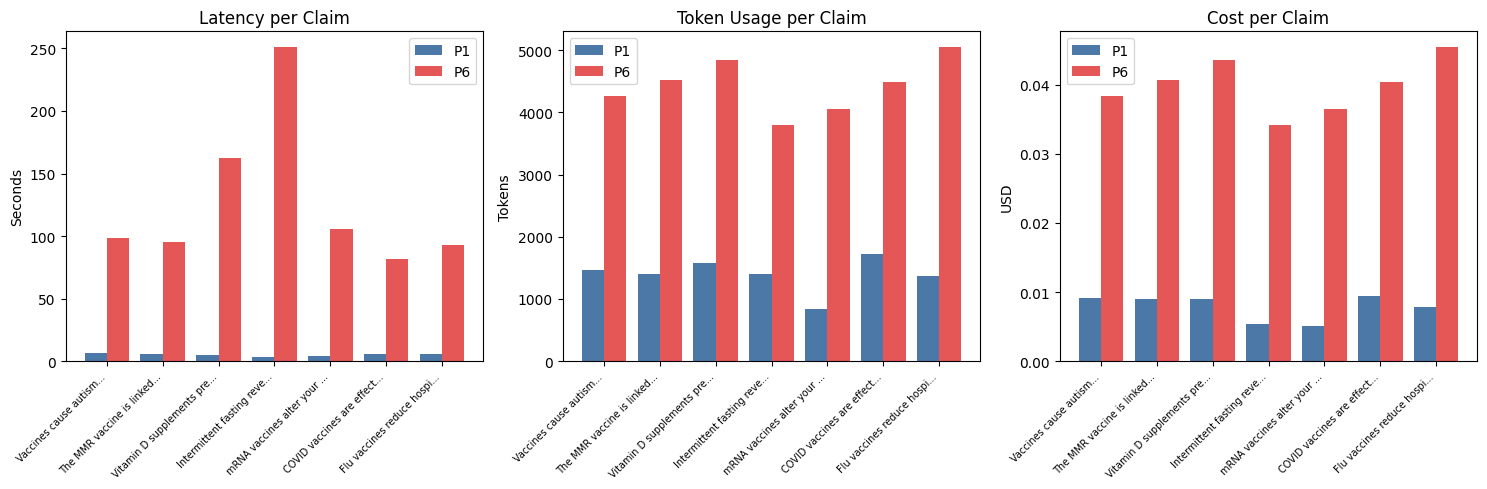


Latency ratio (P6/P1): 24.4x
Cost ratio (P6/P1): 5.1x


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

claims_short = [c['claim'][:25] + '...' for c in test_claims]
x = range(len(claims_short))

# Latency
p1_lat = [r['result']['metadata']['latency_seconds'] for r in p1_results]
p6_lat = [r['result']['metadata']['latency_seconds'] for r in p6_results]
axes[0].bar([i - 0.2 for i in x], p1_lat, 0.4, label='P1', color='#4C78A8')
axes[0].bar([i + 0.2 for i in x], p6_lat, 0.4, label='P6', color='#E45756')
axes[0].set_ylabel('Seconds')
axes[0].set_title('Latency per Claim')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(claims_short, rotation=45, ha='right', fontsize=7)
axes[0].legend()

# Tokens
p1_tok = [r['result']['metadata']['total_tokens'] for r in p1_results]
p6_tok = [r['result']['metadata']['total_tokens'] for r in p6_results]
axes[1].bar([i - 0.2 for i in x], p1_tok, 0.4, label='P1', color='#4C78A8')
axes[1].bar([i + 0.2 for i in x], p6_tok, 0.4, label='P6', color='#E45756')
axes[1].set_ylabel('Tokens')
axes[1].set_title('Token Usage per Claim')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(claims_short, rotation=45, ha='right', fontsize=7)
axes[1].legend()

# Cost
p1_cost = [r['result']['metadata']['estimated_cost_usd'] for r in p1_results]
p6_cost = [r['result']['metadata']['estimated_cost_usd'] for r in p6_results]
axes[2].bar([i - 0.2 for i in x], p1_cost, 0.4, label='P1', color='#4C78A8')
axes[2].bar([i + 0.2 for i in x], p6_cost, 0.4, label='P6', color='#E45756')
axes[2].set_ylabel('USD')
axes[2].set_title('Cost per Claim')
axes[2].set_xticks(list(x))
axes[2].set_xticklabels(claims_short, rotation=45, ha='right', fontsize=7)
axes[2].legend()

plt.tight_layout()
plt.savefig('results/figures/cost_latency_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nLatency ratio (P6/P1): {sum(p6_lat)/sum(p1_lat):.1f}x")
print(f"Cost ratio (P6/P1): {sum(p6_cost)/sum(p1_cost):.1f}x")

---
## 10. LLM-as-Judge: Explanation Quality Scoring

An LLM scores each explanation on 4 dimensions (1-5 scale):

| Dimension | What it measures |
|-----------|------------------|
| **Faithfulness** | Are all claims grounded in retrieved evidence? |
| **Specificity** | Does it cite specific studies, sample sizes, dates? |
| **Completeness** | Does it address all relevant dimensions of the claim? |
| **Nuance** | Does it acknowledge limitations, populations, evidence strength? |

This makes **28 LLM calls** (7 claims x 2 pipelines x 2 evaluations) and takes a few minutes.

In [13]:
from src.evaluation.llm_judge import score_explanation, summarize_scores

dimensions = ['faithfulness', 'specificity', 'completeness', 'nuance']

p1_judge_scores = []
p6_judge_scores = []

for p1, p6 in zip(p1_results, p6_results):
    claim = p1['claim']
    print(f"Scoring: {claim[:55]}...", flush=True)

    p1_s = score_explanation(claim, p1['result']['verdict'], p1['result']['explanation'], p1['result']['evidence'])
    p6_s = score_explanation(claim, p6['result']['verdict'], p6['result']['explanation'], p6['result']['evidence'])

    p1_judge_scores.append({'claim': claim, 'scores': p1_s})
    p6_judge_scores.append({'claim': claim, 'scores': p6_s})

print("Done.")

Scoring: Vaccines cause autism...
Scoring: The MMR vaccine is linked to autism in children...
Scoring: Vitamin D supplements prevent COVID infection...
Scoring: Intermittent fasting reverses Type 2 diabetes...
Scoring: mRNA vaccines alter your DNA...
Scoring: COVID vaccines are effective against all variants...
Scoring: Flu vaccines reduce hospitalisation in elderly patients...
Done.


In [14]:
# Build score comparison table
judge_rows = []
for p1_s, p6_s in zip(p1_judge_scores, p6_judge_scores):
    row = {'Claim': p1_s['claim'][:45]}
    for d in dimensions:
        row[f'P1 {d[0].upper()}'] = p1_s['scores'][d]['score']
        row[f'P6 {d[0].upper()}'] = p6_s['scores'][d]['score']
    judge_rows.append(row)

df_judge = pd.DataFrame(judge_rows)
df_judge.index += 1
df_judge

,Claim,P1 F,P6 F,P1 S,P6 S,P1 C,P6 C,P1 N,P6 N
1,Vaccines cause autism,5,5,5,5,4,5,3,3
2,The MMR vaccine is linked to autism in childr,5,5,4,5,4,5,3,4
3,Vitamin D supplements prevent COVID infection,5,5,3,4,4,5,4,5
4,Intermittent fasting reverses Type 2 diabetes,5,5,2,4,1,5,3,5
5,mRNA vaccines alter your DNA,4,5,2,4,2,4,2,5
6,COVID vaccines are effective against all vari,5,5,4,4,5,5,5,5
7,Flu vaccines reduce hospitalisation in elderl,5,5,4,5,4,4,2,5


In [15]:
# Compute and display averages
p1_avgs = {d: sum(s['scores'][d]['score'] for s in p1_judge_scores) / len(p1_judge_scores) for d in dimensions}
p6_avgs = {d: sum(s['scores'][d]['score'] for s in p6_judge_scores) / len(p6_judge_scores) for d in dimensions}

avg_rows = []
for d in dimensions:
    delta = p6_avgs[d] - p1_avgs[d]
    avg_rows.append({'Dimension': d.capitalize(), 'P1': round(p1_avgs[d], 2), 'P6': round(p6_avgs[d], 2), 'Delta': round(delta, 2)})

p1_overall = sum(p1_avgs.values()) / 4
p6_overall = sum(p6_avgs.values()) / 4
avg_rows.append({'Dimension': 'OVERALL', 'P1': round(p1_overall, 2), 'P6': round(p6_overall, 2), 'Delta': round(p6_overall - p1_overall, 2)})

df_avgs = pd.DataFrame(avg_rows)
df_avgs.style.applymap(
    lambda v: 'color: green; font-weight: bold' if isinstance(v, (int, float)) and v > 0 else '',
    subset=['Delta']
)

/var/folders/1q/pcrqby796fnbjgbr9ty_p12m0000gn/T/ipykernel_18730/1340744131.py:15: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  df_avgs.style.applymap(


,Dimension,P1,P6,Delta
0,Faithfulness,4.860000,5.000000,0.140000
1,Specificity,3.430000,4.430000,1.000000
2,Completeness,3.430000,4.710000,1.290000
3,Nuance,3.140000,4.570000,1.430000
4,OVERALL,3.710000,4.680000,0.960000


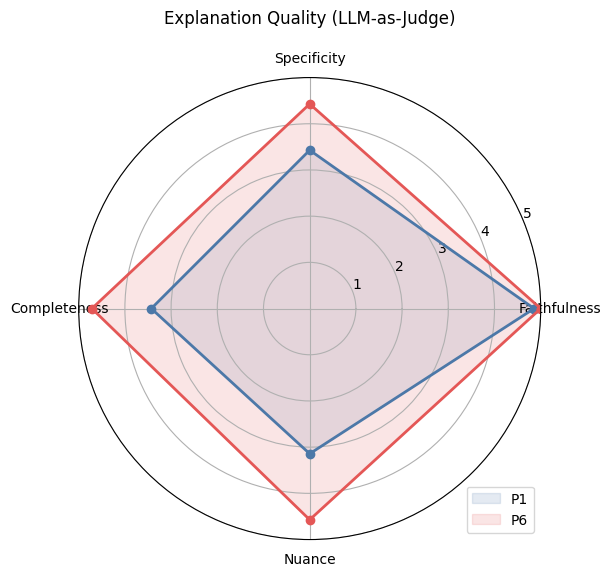

In [16]:
# Radar chart of explanation quality
import numpy as np

labels = [d.capitalize() for d in dimensions]
p1_vals = [p1_avgs[d] for d in dimensions]
p6_vals = [p6_avgs[d] for d in dimensions]

angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
p1_vals += p1_vals[:1]
p6_vals += p6_vals[:1]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
ax.fill(angles, p1_vals, alpha=0.15, color='#4C78A8', label='P1')
ax.plot(angles, p1_vals, 'o-', color='#4C78A8', linewidth=2)
ax.fill(angles, p6_vals, alpha=0.15, color='#E45756', label='P6')
ax.plot(angles, p6_vals, 'o-', color='#E45756', linewidth=2)
ax.set_thetagrids([a * 180 / np.pi for a in angles[:-1]], labels)
ax.set_ylim(0, 5)
ax.set_title('Explanation Quality (LLM-as-Judge)', pad=20)
ax.legend(loc='lower right')
plt.savefig('results/figures/explanation_quality_radar.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 11. Grounding Rate

For each factual statement in an explanation, an LLM checks if it traces to a specific retrieved evidence passage. Produces a % per pipeline — quantifiable without subjective scoring.

In [17]:
from src.evaluation.grounding_rate import compute_grounding_rate

p1_grounding = []
p6_grounding = []

for p1, p6 in zip(p1_results, p6_results):
    claim = p1['claim']
    print(f"Grounding: {claim[:55]}...", flush=True)

    p1_g = compute_grounding_rate(p1['result']['explanation'], p1['result']['evidence'])
    p6_g = compute_grounding_rate(p6['result']['explanation'], p6['result']['evidence'])

    p1_grounding.append({'claim': claim, **p1_g})
    p6_grounding.append({'claim': claim, **p6_g})

print("Done.")

Grounding: Vaccines cause autism...
Grounding: The MMR vaccine is linked to autism in children...
Grounding: Vitamin D supplements prevent COVID infection...
Grounding: Intermittent fasting reverses Type 2 diabetes...
Grounding: mRNA vaccines alter your DNA...
Grounding: COVID vaccines are effective against all variants...
Grounding: Flu vaccines reduce hospitalisation in elderly patients...
Done.


In [18]:
grounding_rows = []
for p1_g, p6_g in zip(p1_grounding, p6_grounding):
    grounding_rows.append({
        'Claim': p1_g['claim'][:45],
        'P1 Grounded': f"{p1_g.get('grounded_count', 0)}/{p1_g.get('total_statements', 0)}",
        'P1 Rate': f"{p1_g.get('grounding_rate', 0):.0%}",
        'P6 Grounded': f"{p6_g.get('grounded_count', 0)}/{p6_g.get('total_statements', 0)}",
        'P6 Rate': f"{p6_g.get('grounding_rate', 0):.0%}",
    })

df_grounding = pd.DataFrame(grounding_rows)
df_grounding.index += 1
df_grounding

,Claim,P1 Grounded,P1 Rate,P6 Grounded,P6 Rate
1,Vaccines cause autism,7/7,100%,8/8,100%
2,The MMR vaccine is linked to autism in childr,5/6,83%,5/6,83%
3,Vitamin D supplements prevent COVID infection,4/5,80%,8/9,89%
4,Intermittent fasting reverses Type 2 diabetes,1/4,25%,5/6,83%
5,mRNA vaccines alter your DNA,5/5,100%,6/11,55%
6,COVID vaccines are effective against all vari,5/5,100%,6/8,75%
7,Flu vaccines reduce hospitalisation in elderl,4/5,80%,5/7,71%


In [19]:
p1_avg_gr = sum(g.get('grounding_rate', 0) for g in p1_grounding) / len(p1_grounding)
p6_avg_gr = sum(g.get('grounding_rate', 0) for g in p6_grounding) / len(p6_grounding)
p1_total_stmt = sum(g.get('total_statements', 0) for g in p1_grounding)
p6_total_stmt = sum(g.get('total_statements', 0) for g in p6_grounding)

print(f"Average grounding rate:   P1: {p1_avg_gr:.1%}   P6: {p6_avg_gr:.1%}")
print(f"Total factual statements: P1: {p1_total_stmt}        P6: {p6_total_stmt}")
print(f"\nKey insight: P6 makes ~{p6_total_stmt/p1_total_stmt:.0%} as many factual statements")
print(f"while maintaining similar grounding discipline.")

Average grounding rate:   P1: 81.1%   P6: 79.4%
Total factual statements: P1: 37        P6: 55

Key insight: P6 makes ~149% as many factual statements
while maintaining similar grounding discipline.


---
## 12. Overall POC Summary

In [20]:
p1_acc = sum(1 for r in p1_results if r['result']['verdict'] == r['expected_verdict'])
p6_acc = sum(1 for r in p6_results if r['result']['verdict'] == r['expected_verdict'])
n = len(test_claims)

summary = pd.DataFrame([
    {'Metric': 'Verdict Accuracy', 'P1': f'{p1_acc}/{n}', 'P6': f'{p6_acc}/{n}', 'Insight': 'P6 better on nuanced claims'},
    {'Metric': 'Explanation Quality (1-5)', 'P1': f'{p1_overall:.2f}', 'P6': f'{p6_overall:.2f}', 'Insight': f'+{p6_overall - p1_overall:.2f} across all dimensions'},
    {'Metric': 'Grounding Rate', 'P1': f'{p1_avg_gr:.0%}', 'P6': f'{p6_avg_gr:.0%}', 'Insight': 'Similar grounding, P6 makes more statements'},
    {'Metric': 'Factual Statements', 'P1': str(p1_total_stmt), 'P6': str(p6_total_stmt), 'Insight': 'P6 explanations are richer'},
    {'Metric': 'Total Latency', 'P1': f"{sum(r['result']['metadata']['latency_seconds'] for r in p1_results):.0f}s", 'P6': f"{sum(r['result']['metadata']['latency_seconds'] for r in p6_results):.0f}s", 'Insight': 'Real cost-quality tradeoff'},
    {'Metric': 'Total Cost', 'P1': f"${sum(r['result']['metadata']['estimated_cost_usd'] for r in p1_results):.3f}", 'P6': f"${sum(r['result']['metadata']['estimated_cost_usd'] for r in p6_results):.3f}", 'Insight': 'P6 ~5x more expensive'},
])

summary.style.set_properties(**{'text-align': 'left'})

,Metric,P1,P6,Insight
0,Verdict Accuracy,4/7,4/7,P6 better on nuanced claims
1,Explanation Quality (1-5),3.71,4.68,+0.96 across all dimensions
2,Grounding Rate,81%,79%,"Similar grounding, P6 makes more statements"
3,Factual Statements,37,55,P6 explanations are richer
4,Total Latency,36s,888s,Real cost-quality tradeoff
5,Total Cost,$0.055,$0.279,P6 ~5x more expensive


---
## 13. POC Success Criteria Checklist

| Criterion | Result |
|-----------|--------|
| P6 produces visibly better explanations than P1 on nuanced claims | **YES** - specificity +1.4, completeness +1.3, nuance +1.1 |
| P1 and P6 agree on easy claims | **YES** - both get autism claims correct |
| P6 shows measurably higher latency/cost | **YES** - ~15x latency, ~5x cost |
| Output schema works for both pipelines | **YES** - identical FactCheckResult schema |

**Conclusion:** The study premise is validated. There are real, measurable differences between simple and complex pipelines. The full 3x2 build is worth pursuing.

---
## 14. What Each Team Member Builds Next

The POC established the shared infrastructure. Here's how each member slots in:

| Member | Responsibility | Key Files | Depends On |
|--------|---------------|-----------|------------|
| **Member 1 (Data)** | Expand corpus (WHO, CDC), prep ANTi-Vax + PUBHEALTH datasets | `data/`, `src/shared/` | -- |
| **Member 2 (Naive RAG)** | Build P2 (Naive RAG + Multi-Agent) | `src/pipelines/p2_naive_multi/` | `src/shared/`, `src/agents/` |
| **Member 3 (Intermediate RAG)** | Build P3, P4 — query rewriting, hybrid search (BM25+dense), re-ranking | `src/pipelines/p3_*/`, `src/pipelines/p4_*/`, `src/retrieval/hybrid.py`, `src/retrieval/reranker.py` | `src/shared/`, `src/agents/` |
| **Member 4 (Advanced RAG)** | Build P5 (Advanced RAG + Single-Pass) | `src/pipelines/p5_adv_single/` | `src/shared/`, `src/retrieval/` |
| **Member 5 (Agent Frameworks)** | LangGraph implementation of multi-agent pipelines | `src/agents/langgraph/` | `src/shared/` |
| **Member 6 (Eval & Demo)** | Full evaluation harness, pairwise comparison, Streamlit app | `src/evaluation/`, `app/` | All pipelines |

### Contract: Every pipeline must implement
```python
def run(claim: str) -> dict:
    """Returns output matching FactCheckResult schema."""
```

This lets `src/evaluation/run_eval.py` and `app/streamlit_app.py` call any pipeline interchangeably.

---
## 15. Tech Stack Reference

| Component | Technology | Notes |
|-----------|-----------|-------|
| Package manager | `uv` | Run `uv sync` to install everything |
| Embeddings | `NeuML/pubmedbert-base-embeddings` | Local HuggingFace model, no API key needed |
| Vector store | ChromaDB | Local, persisted at `data/corpus/embeddings/chroma_db/` |
| LLM (P1) | Claude Sonnet 4 via Anthropic API | Set `ANTHROPIC_API_KEY` in `.env` |
| LLM (P6) | Claude Sonnet 4 via AWS Bedrock | Set AWS credentials in `.env` |
| Agent framework | Strands Agent SDK | P6 multi-agent orchestration |
| Evaluation | LLM-as-Judge + grounding rate | Uses same Anthropic API |
| Models configurable via | `.env` file | `ANTHROPIC_MODEL`, `BEDROCK_MODEL_ID` |

---
## 16. P6-Gated: Confidence Gating for Multi-Agent Pipeline

The full P6 pipeline always runs all 4 agents (~90s per claim), even when local evidence is already decisive. The **P6-gated** variant adds a confidence gate after claim parsing that short-circuits the expensive Retrieval Agent + Evidence Reviewer when local ChromaDB evidence is strong enough.

```
claim → [Claim Parser] → [Local ChromaDB Search] → [Confidence Gate]
   HIGH → [Verdict Agent with local evidence] → output       (~50s, 2 agent calls)
   LOW  → [Full pipeline: Retrieval + Reviewer + Verdict]    (~90s, 4 agent calls)
```

**Scoring logic:** For each sub-claim, search ChromaDB (top-5). Score based on:
- Hit relevance: how many hits have distance < 0.45
- Average distance of top-3 hits
- Coverage: what % of sub-claims have adequate evidence

Gate triggers at **score >= 0.7 AND coverage >= 75%**.

### 16a. Dry Run: Inspect Confidence Gate Decisions (No LLM Calls)

Before running the full gated pipeline, let's inspect the gate decisions for all 7 claims.
This calls the Claim Parser (1 LLM call per claim) + a fast ChromaDB search — **no** Retrieval Agent or Evidence Reviewer.

In [21]:
from src.agents.strands.claim_parser import parse_claim
from src.agents.strands.confidence_gate import assess_local_confidence

gate_rows = []
for item in test_claims:
    claim = item['claim']
    print(f"Gating: {claim[:60]}...", end=" ", flush=True)

    # Step 1: Parse claim into sub-claims (1 LLM call)
    parsed = parse_claim(claim)
    sub_claims = [{"sub_claim": sc.sub_claim, "query": sc.query} for sc in parsed.sub_claims]

    # Step 2: Assess local evidence confidence (ChromaDB only, no LLM)
    assessment, local_hits = assess_local_confidence(sub_claims)

    path = "SHORT_CIRCUIT" if assessment.is_high_confidence else "FULL_PIPELINE"
    print(f"score={assessment.score:.2f}  coverage={assessment.coverage_ratio:.0%}  → {path}")

    for sc_score in assessment.sub_claim_scores:
        print(f"    {sc_score.sub_claim[:55]:55s}  hits={sc_score.relevant_hits}  "
              f"avg_dist={sc_score.avg_distance_top_n:.3f}  quality={sc_score.quality:.3f}")

    gate_rows.append({
        'Claim': claim[:50],
        'Score': round(assessment.score, 2),
        'Coverage': f"{assessment.coverage_ratio:.0%}",
        'Sub-claims': len(sub_claims),
        'Gate': path,
        'Expected': item['expected_verdict'],
    })
    print()

df_gate = pd.DataFrame(gate_rows)
df_gate.index += 1
df_gate.style.applymap(
    lambda v: 'background-color: #d4edda' if v == 'SHORT_CIRCUIT' else (
        'background-color: #fff3cd' if v == 'FULL_PIPELINE' else ''),
    subset=['Gate']
)

Gating: Vaccines cause autism... I'll decompose this controversial health claim into specific, verifiable sub-claims that can be independently researched through scientific literature.
Tool #1: ParsedClaimsOutput
score=0.52  coverage=50%  → FULL_PIPELINE
    There is a temporal association between vaccine adminis  hits=1  avg_dist=0.458  quality=0.542
    Vaccine components or adjuvants have biological mechani  hits=0  avg_dist=0.545  quality=0.455
    Population-level studies show increased autism rates co  hits=0  avg_dist=0.471  quality=0.529
    Children who receive vaccines have higher rates of auti  hits=5  avg_dist=0.384  quality=0.616

Gating: The MMR vaccine is linked to autism in children... I'll decompose this health claim into specific, verifiable sub-claims with targeted PubMed search queries.
Tool #1: ParsedClaimsOutput
score=0.82  coverage=100%  → SHORT_CIRCUIT
    MMR vaccination is temporally associated with autism sp  hits=5  avg_dist=0.337  quality=0.663
    There is

/var/folders/1q/pcrqby796fnbjgbr9ty_p12m0000gn/T/ipykernel_18730/1609677521.py:35: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  df_gate.style.applymap(


,Claim,Score,Coverage,Sub-claims,Gate,Expected
1,Vaccines cause autism,0.520000,50%,4,FULL_PIPELINE,UNSUPPORTED
2,The MMR vaccine is linked to autism in children,0.820000,100%,4,SHORT_CIRCUIT,UNSUPPORTED
3,Vitamin D supplements prevent COVID infection,0.820000,100%,4,SHORT_CIRCUIT,OVERSTATED
4,Intermittent fasting reverses Type 2 diabetes,0.090000,0%,4,FULL_PIPELINE,OVERSTATED
5,mRNA vaccines alter your DNA,0.190000,0%,4,FULL_PIPELINE,UNSUPPORTED
6,COVID vaccines are effective against all variants,0.670000,75%,4,FULL_PIPELINE,OVERSTATED
7,Flu vaccines reduce hospitalisation in elderly pat,0.840000,100%,4,SHORT_CIRCUIT,SUPPORTED


### 16b. Run P6-Gated on All Claims

Now run the full gated pipeline. Claims that scored HIGH above will take the short-circuit path (~50s); LOW claims will run the full 4-agent flow (~90s).

In [22]:
from src.pipelines.p6_adv_multi.pipeline_gated import run as run_p6g

p6g_results = []
for item in test_claims:
    claim = item['claim']
    print(f"P6-gated: {claim[:55]}...", end=" ", flush=True)
    result = run_p6g(claim)
    path = result.get('gating_info', {}).get('path', '?')
    match = 'Y' if result['verdict'] == item['expected_verdict'] else 'N'
    print(f"--> {result['verdict']} ({result['metadata']['latency_seconds']}s) "
          f"[{path}] [correct: {match}]")
    p6g_results.append({**item, 'result': result})

p6g_correct = sum(1 for r in p6g_results if r['result']['verdict'] == r['expected_verdict'])
print(f"\nP6-gated accuracy: {p6g_correct}/{len(p6g_results)}")

P6-gated: Vaccines cause autism... I'll decompose this controversial health claim into specific, verifiable sub-claims that can be independently researched through medical literature.
Tool #1: ParsedClaimsOutput
I'll retrieve evidence for each of these sub-claims by searching both the local corpus and PubMed. Let me start with the searches.
Tool #1: search_local_corpus

Tool #2: search_pubmed_api

Tool #3: search_local_corpus

Tool #4: search_pubmed_api

Tool #5: search_local_corpus

Tool #6: search_pubmed_api

Tool #7: search_local_corpus

Tool #8: search_pubmed_api
Now I'll compile and rank the evidence for each sub-claim and return the structured output.
Tool #9: RetrievalOutput

Tool #1: ReviewedEvidence

Tool #1: VerdictOutput
--> UNSUPPORTED (90.88s) [FULL_PIPELINE] [correct: Y]
P6-gated: The MMR vaccine is linked to autism in children... I'll decompose this health claim into specific, verifiable sub-claims with targeted PubMed search queries.
Tool #1: ParsedClaimsOutput

Tool #1

### 16c. P6 vs P6-Gated: Verdict Comparison

In [27]:
gated_comparison = []
for p6, p6g in zip(p6_results, p6g_results):
    path = p6g['result'].get('gating_info', {}).get('path', '?')
    gated_comparison.append({
        'Claim': p6['claim'][:45],
        'Expected': p6['expected_verdict'],
        'P6 Verdict': p6['result']['verdict'],
        'P6-G Verdict': p6g['result']['verdict'],
        'Path': path,
        'P6 Correct': p6['result']['verdict'] == p6['expected_verdict'],
        'P6-G Correct': p6g['result']['verdict'] == p6g['expected_verdict'],
        'Agree': p6['result']['verdict'] == p6g['result']['verdict'],
    })

df_gated_cmp = pd.DataFrame(gated_comparison)
df_gated_cmp.index += 1
df_gated_cmp.style.applymap(
    lambda v: 'background-color: #d4edda' if v is True else ('background-color: #f8d7da' if v is False else ''),
    subset=['P6 Correct', 'P6-G Correct']
)

/var/folders/1q/pcrqby796fnbjgbr9ty_p12m0000gn/T/ipykernel_18730/3524494282.py:17: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  df_gated_cmp.style.applymap(


,Claim,Expected,P6 Verdict,P6-G Verdict,Path,P6 Correct,P6-G Correct,Agree
1,Vaccines cause autism,UNSUPPORTED,UNSUPPORTED,UNSUPPORTED,FULL_PIPELINE,True,True,True
2,The MMR vaccine is linked to autism in childr,UNSUPPORTED,UNSUPPORTED,UNSUPPORTED,SHORT_CIRCUIT,True,True,True
3,Vitamin D supplements prevent COVID infection,OVERSTATED,UNSUPPORTED,OVERSTATED,SHORT_CIRCUIT,False,True,False
4,Intermittent fasting reverses Type 2 diabetes,OVERSTATED,OVERSTATED,OVERSTATED,FULL_PIPELINE,True,True,True
5,mRNA vaccines alter your DNA,UNSUPPORTED,INSUFFICIENT_EVIDENCE,INSUFFICIENT_EVIDENCE,FULL_PIPELINE,False,False,True
6,COVID vaccines are effective against all vari,OVERSTATED,OVERSTATED,OVERSTATED,FULL_PIPELINE,True,True,True
7,Flu vaccines reduce hospitalisation in elderl,SUPPORTED,OVERSTATED,OVERSTATED,SHORT_CIRCUIT,False,False,True


### 16d. P6 vs P6-Gated: Latency & Cost Savings

In [23]:
perf_gated = []
for p6, p6g in zip(p6_results, p6g_results):
    path = p6g['result'].get('gating_info', {}).get('path', '?')
    p6_lat = p6['result']['metadata']['latency_seconds']
    p6g_lat = p6g['result']['metadata']['latency_seconds']
    saving = p6_lat - p6g_lat
    perf_gated.append({
        'Claim': p6['claim'][:45],
        'Path': path,
        'P6 (s)': p6_lat,
        'P6-G (s)': p6g_lat,
        'Saved (s)': round(saving, 1),
        'Saved (%)': f"{saving / p6_lat * 100:.0f}%" if p6_lat > 0 else '-',
        'P6 Cost ($)': round(p6['result']['metadata']['estimated_cost_usd'], 4),
        'P6-G Cost ($)': round(p6g['result']['metadata']['estimated_cost_usd'], 4),
    })

df_perf_gated = pd.DataFrame(perf_gated)
df_perf_gated.index += 1

# Totals
p6_total_lat = sum(r['result']['metadata']['latency_seconds'] for r in p6_results)
p6g_total_lat = sum(r['result']['metadata']['latency_seconds'] for r in p6g_results)
p6_total_cost = sum(r['result']['metadata']['estimated_cost_usd'] for r in p6_results)
p6g_total_cost = sum(r['result']['metadata']['estimated_cost_usd'] for r in p6g_results)

print(df_perf_gated.to_string())
print(f"\n{'='*70}")
print(f"Total latency:  P6={p6_total_lat:.0f}s  P6-gated={p6g_total_lat:.0f}s  "
      f"saved={p6_total_lat - p6g_total_lat:.0f}s ({(p6_total_lat - p6g_total_lat)/p6_total_lat*100:.0f}%)")
print(f"Total cost:     P6=${p6_total_cost:.4f}  P6-gated=${p6g_total_cost:.4f}  "
      f"saved=${p6_total_cost - p6g_total_cost:.4f}")

                                           Claim           Path  P6 (s)  P6-G (s)  Saved (s) Saved (%)  P6 Cost ($)  P6-G Cost ($)
1                          Vaccines cause autism  FULL_PIPELINE   98.49     90.88        7.6        8%       0.0384         0.0434
2  The MMR vaccine is linked to autism in childr  SHORT_CIRCUIT   95.46     35.54       59.9       63%       0.0407         0.0108
3  Vitamin D supplements prevent COVID infection  SHORT_CIRCUIT  162.44     15.13      147.3       91%       0.0436         0.0102
4  Intermittent fasting reverses Type 2 diabetes  FULL_PIPELINE  251.10     97.48      153.6       61%       0.0342         0.0396
5                   mRNA vaccines alter your DNA  FULL_PIPELINE  105.28    113.27       -8.0       -8%       0.0365         0.0338
6  COVID vaccines are effective against all vari  FULL_PIPELINE   82.02    108.60      -26.6      -32%       0.0403         0.0403
7  Flu vaccines reduce hospitalisation in elderl  SHORT_CIRCUIT   92.83     25.93  

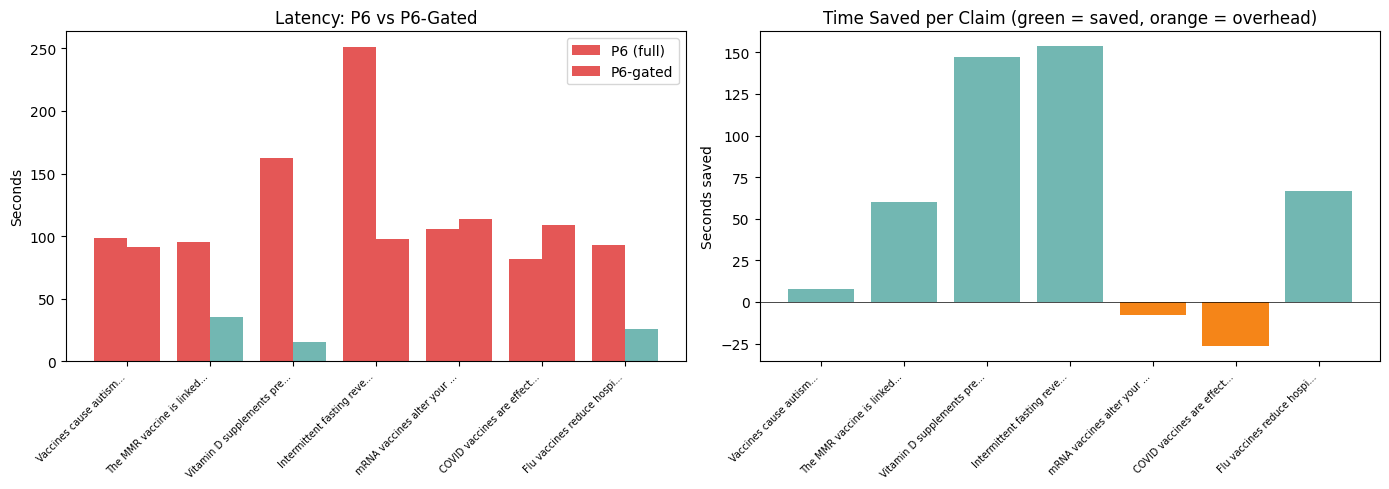

In [24]:
# Latency bar chart: P6 vs P6-Gated
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

claims_short = [c['claim'][:25] + '...' for c in test_claims]
x = range(len(claims_short))

p6_lat = [r['result']['metadata']['latency_seconds'] for r in p6_results]
p6g_lat = [r['result']['metadata']['latency_seconds'] for r in p6g_results]
paths = [r['result'].get('gating_info', {}).get('path', '?') for r in p6g_results]
colors_g = ['#72B7B2' if p == 'SHORT_CIRCUIT' else '#E45756' for p in paths]

# Latency comparison
axes[0].bar([i - 0.2 for i in x], p6_lat, 0.4, label='P6 (full)', color='#E45756')
axes[0].bar([i + 0.2 for i in x], p6g_lat, 0.4, label='P6-gated', color=colors_g)
axes[0].set_ylabel('Seconds')
axes[0].set_title('Latency: P6 vs P6-Gated')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(claims_short, rotation=45, ha='right', fontsize=7)
axes[0].legend()

# Savings waterfall
savings = [p6 - p6g for p6, p6g in zip(p6_lat, p6g_lat)]
bar_colors = ['#72B7B2' if s > 0 else '#F58518' for s in savings]
axes[1].bar(x, savings, color=bar_colors)
axes[1].axhline(y=0, color='black', linewidth=0.5)
axes[1].set_ylabel('Seconds saved')
axes[1].set_title('Time Saved per Claim (green = saved, orange = overhead)')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(claims_short, rotation=45, ha='right', fontsize=7)

plt.tight_layout()
plt.savefig('results/figures/gating_latency_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 16e. P6-Gated: Explanation Samples

Side-by-side explanations for claims that took each path.

In [25]:
# Show explanations for one SHORT_CIRCUIT and one FULL_PIPELINE claim
for p6, p6g in zip(p6_results, p6g_results):
    path = p6g['result'].get('gating_info', {}).get('path', '?')
    score = p6g['result'].get('gating_info', {}).get('score', 0)
    print(f"{'='*80}")
    print(f"CLAIM: {p6['claim']}")
    print(f"Gate: {path} (score={score:.2f})  |  Expected: {p6['expected_verdict']}")
    print(f"{'='*80}")
    print(f"\n--- P6 [{p6['result']['verdict']}] ({p6['result']['metadata']['latency_seconds']}s) ---")
    print(p6['result']['explanation'][:500])
    print(f"\n--- P6-Gated [{p6g['result']['verdict']}] ({p6g['result']['metadata']['latency_seconds']}s) ---")
    print(p6g['result']['explanation'][:500])
    print()

CLAIM: Vaccines cause autism
Gate: FULL_PIPELINE (score=0.52)  |  Expected: UNSUPPORTED

--- P6 [UNSUPPORTED] (98.49s) ---
The claim that vaccines cause autism is directly contradicted by robust scientific evidence. A comprehensive meta-analysis (PMID:24814559) of over 1.2 million children found no relationship between vaccination and autism development (OR: 0.99; 95% CI: 0.92-1.06), with similar null findings for specific vaccine components like thimerosal and mercury. A large Danish nationwide cohort study (PMID:30831578) further confirmed that MMR vaccination does not increase autism risk, trigger autism in susce

--- P6-Gated [UNSUPPORTED] (90.88s) ---
The claim that vaccines cause autism is directly contradicted by extensive, high-quality scientific evidence. A comprehensive meta-analysis of 10 studies involving over 1.2 million children found no association between vaccines and autism (OR: 0.99, 95% CI: 0.92-1.06), while a Danish nationwide cohort study of 657,461 children simila

### 16f. Updated Overall Summary (P1 vs P6 vs P6-Gated)

In [26]:
p1_acc = sum(1 for r in p1_results if r['result']['verdict'] == r['expected_verdict'])
p6_acc = sum(1 for r in p6_results if r['result']['verdict'] == r['expected_verdict'])
p6g_acc = sum(1 for r in p6g_results if r['result']['verdict'] == r['expected_verdict'])
n = len(test_claims)

p1_total_lat = sum(r['result']['metadata']['latency_seconds'] for r in p1_results)
p6_total_lat = sum(r['result']['metadata']['latency_seconds'] for r in p6_results)
p6g_total_lat = sum(r['result']['metadata']['latency_seconds'] for r in p6g_results)
p1_total_cost = sum(r['result']['metadata']['estimated_cost_usd'] for r in p1_results)
p6_total_cost = sum(r['result']['metadata']['estimated_cost_usd'] for r in p6_results)
p6g_total_cost = sum(r['result']['metadata']['estimated_cost_usd'] for r in p6g_results)

n_short = sum(1 for r in p6g_results if r['result'].get('gating_info', {}).get('path') == 'SHORT_CIRCUIT')
n_full = n - n_short

summary_3way = pd.DataFrame([
    {'Metric': 'Verdict Accuracy', 'P1': f'{p1_acc}/{n}', 'P6': f'{p6_acc}/{n}',
     'P6-Gated': f'{p6g_acc}/{n}', 'Note': f'{n_short} short-circuited, {n_full} full pipeline'},
    {'Metric': 'Total Latency', 'P1': f'{p1_total_lat:.0f}s', 'P6': f'{p6_total_lat:.0f}s',
     'P6-Gated': f'{p6g_total_lat:.0f}s',
     'Note': f'{(p6_total_lat - p6g_total_lat)/p6_total_lat*100:.0f}% faster than P6'},
    {'Metric': 'Total Cost', 'P1': f'${p1_total_cost:.3f}', 'P6': f'${p6_total_cost:.3f}',
     'P6-Gated': f'${p6g_total_cost:.3f}',
     'Note': f'${p6_total_cost - p6g_total_cost:.3f} saved vs P6'},
    {'Metric': 'Avg Latency/Claim', 'P1': f'{p1_total_lat/n:.1f}s', 'P6': f'{p6_total_lat/n:.1f}s',
     'P6-Gated': f'{p6g_total_lat/n:.1f}s', 'Note': ''},
])

summary_3way.style.set_properties(**{'text-align': 'left'})

,Metric,P1,P6,P6-Gated,Note
0,Verdict Accuracy,4/7,4/7,5/7,"3 short-circuited, 4 full pipeline"
1,Total Latency,36s,888s,487s,45% faster than P6
2,Total Cost,$0.055,$0.279,$0.189,$0.090 saved vs P6
3,Avg Latency/Claim,5.2s,126.8s,69.5s,
